# TP3 – Detección del logotipo de Coca-Cola


Buscamos localizar el logotipo dentro de todas las imágenes provistas (`images`) a partir del template (`template/pattern.png`). El objetivo es obtener una detección confiable en cada imagen sin producir falsos positivos.


## Punto 1

Procesando: coca_multi.png
Iteración 1 → SIFT Invertido | 10 matches
Iteración 2 → SIFT Invertido | 9 matches
Iteración 3 → SIFT Invertido | 8 matches
Iteración 4 → SIFT Invertido | 9 matches
Iteración 5 → SIFT Invertido | 13 matches
Iteración 6 → SIFT Invertido | 28 matches
Iteración 7 → SIFT Invertido | 30 matches
Iteración 8 → SIFT Invertido | 31 matches
→ Suficientes matches (31). Termina el zoom.


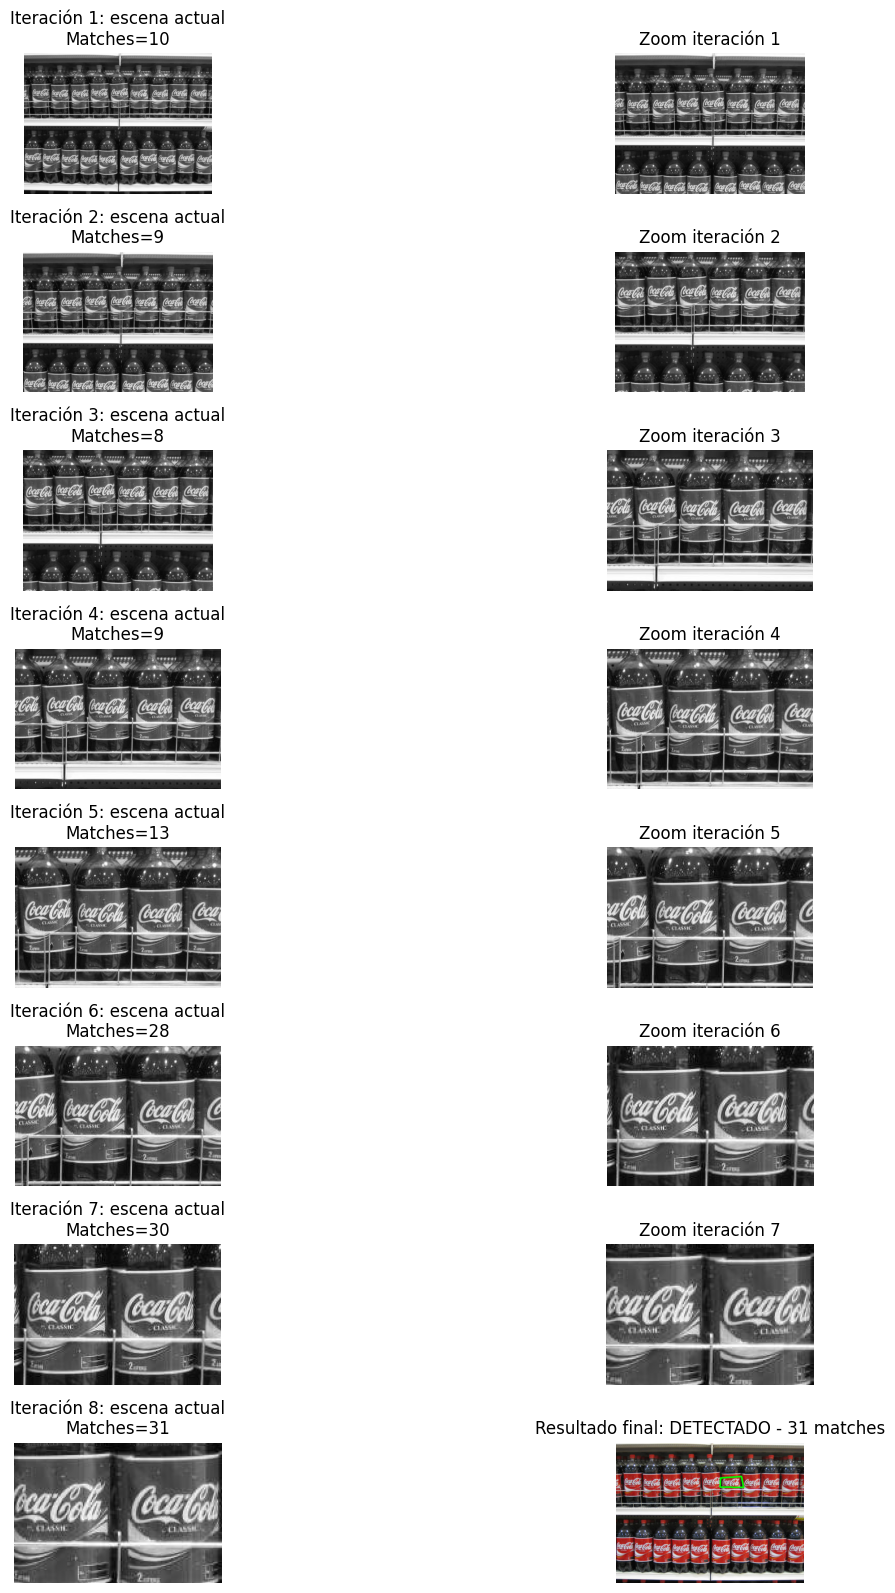

Procesando: coca_logo_1.png
Iteración 1 → SIFT Invertido | 48 matches
→ Suficientes matches (48). Termina el zoom.


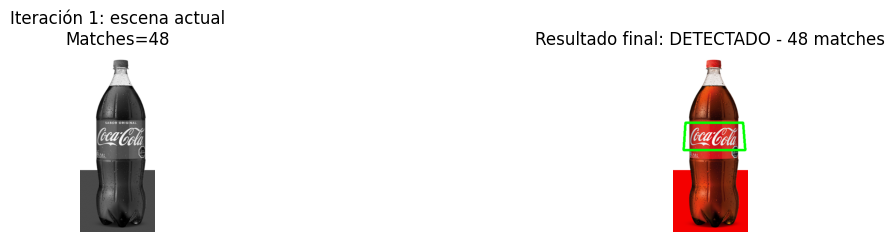

Procesando: coca_retro_1.png
Iteración 1 → SIFT Normal | 34 matches
→ Suficientes matches (34). Termina el zoom.


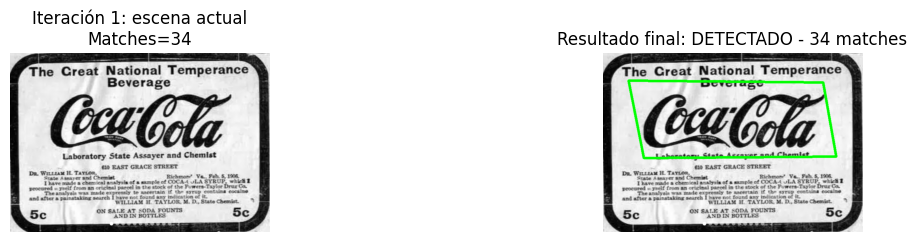

Procesando: logo_1.png
Iteración 1 → SIFT Invertido | 43 matches
→ Suficientes matches (43). Termina el zoom.


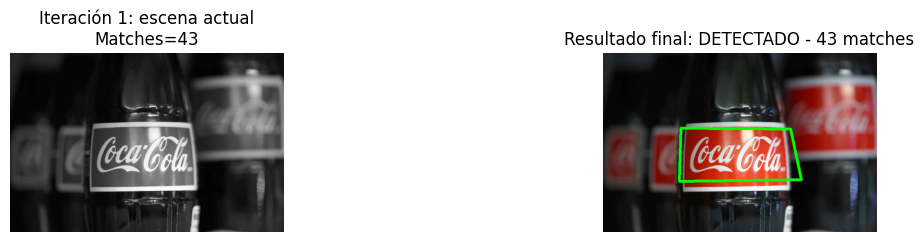

Procesando: coca_logo_2.png
Iteración 1 → SIFT Invertido | 44 matches
→ Suficientes matches (44). Termina el zoom.


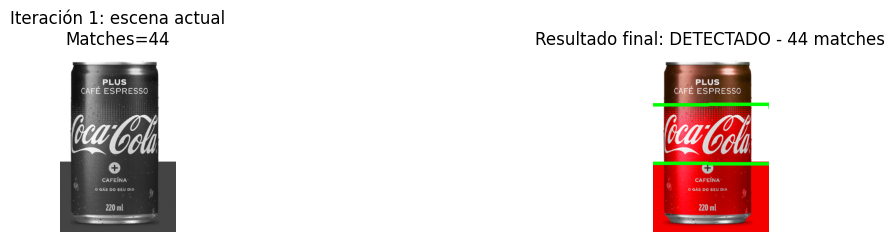

Procesando: coca_retro_2.png
Iteración 1 → SIFT Invertido | 46 matches
→ Suficientes matches (46). Termina el zoom.


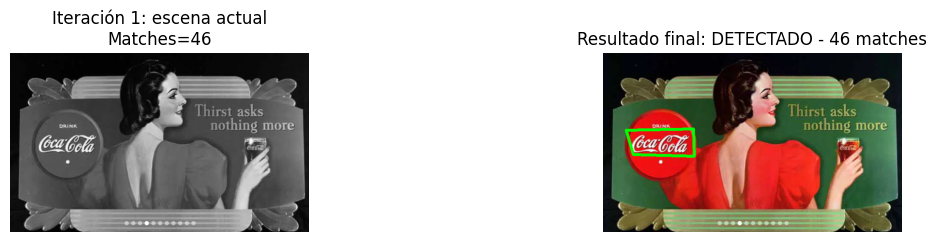

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# --- CONFIGURACIÓN ---
carpeta_imagenes = './images/'
path_template = './template/pattern.png'

# 1. Cargar Template
img_pattern = cv2.imread(path_template)
if img_pattern is None:
    print("Error: No se encontró pattern.png")
    exit()

pattern_gray = cv2.cvtColor(img_pattern, cv2.COLOR_BGR2GRAY)
pattern_inv = cv2.bitwise_not(pattern_gray)
h_t, w_t = pattern_gray.shape

sift = cv2.SIFT_create()

# Se calcula el patron ivnertido y el normal para poder comparar tanto las letras rojas con fondo blanco como las letras negras con fondo blanco. 
kp_t_inv, des_t_inv = sift.detectAndCompute(pattern_inv, None)
kp_t_norm, des_t_norm = sift.detectAndCompute(pattern_gray, None)

bf = cv2.BFMatcher()

archivos = [f for f in os.listdir(carpeta_imagenes) if f.lower().endswith('.png')]

# ------------------------------
# Función para recortar (zoom in) dado un centro
# ------------------------------
def hacer_zoom_desde_centro(img, cx, cy, factor=0.80):
    """
    Hace un zoom recortando un porcentaje (factor) del ancho/alto,
    centrado en (cx, cy) en coordenadas de la imagen actual.
    """
    h, w = img.shape[:2]

    zoom_w = int(w * factor)
    zoom_h = int(h * factor)

    x1 = max(int(cx - zoom_w // 2), 0)
    y1 = max(int(cy - zoom_h // 2), 0)
    x2 = min(int(cx + zoom_w // 2), w)
    y2 = min(int(cy + zoom_h // 2), h)

    recorte = img[y1:y2, x1:x2]

    return recorte, x1, y1, x2, y2

def calcular_centro(kp_s, n_valores):
    cx = sum([kp_s[good[i].trainIdx].pt[0] for i in range(n_valores)]) / n_valores
    cy = sum([kp_s[good[i].trainIdx].pt[1] for i in range(n_valores)]) / n_valores
    return cx, cy

# ----------------------------------------------------------------------
# PROCESAR TODAS LAS IMÁGENES
# ----------------------------------------------------------------------

for archivo in archivos:
    path_full = os.path.join(carpeta_imagenes, archivo)
    img_scene_orig = cv2.imread(path_full)
    img_gray_orig = cv2.cvtColor(img_scene_orig, cv2.COLOR_BGR2GRAY)

    img_scene = img_scene_orig.copy()
    img_gray = img_gray_orig.copy()

    # Desplazamiento acumulado del zoom respecto de la imagen original
    zoom_total_x = 0
    zoom_total_y = 0

    print(f"Procesando: {archivo}")

    fig = plt.figure(figsize=(12, 20))
    subplot_idx = 1

    # Auxs pra mejores resultados
    found_enough = False
    final_kp_s = None
    final_good = None
    final_template_kp = None

    max_iters = 10
    min_matches_for_homography = 31  

    for intento in range(max_iters):

        # 1) Detectar SIFT en la imagen actual (que puede estar recortada)
        kp_s, des_s = sift.detectAndCompute(img_gray, None)

        if des_s is None or len(kp_s) <= 4:
            print(f"Iteración {intento+1}: muy pocos keypoints en la escena ({len(kp_s) if kp_s is not None else 0}).")
            good = []
        else:
            # 2) Matching con template invertido y normal
            matches_inv = bf.knnMatch(des_t_inv, des_s, k=2)
            matches_norm = bf.knnMatch(des_t_norm, des_s, k=2)

            good_inv = []
            for m, n in matches_inv:
                if m.distance < 0.8 * n.distance:
                    good_inv.append(m)

            good_norm = []
            for m, n in matches_norm:
                if m.distance < 0.8 * n.distance:
                    good_norm.append(m)

            good_inv = sorted(good_inv, key=lambda x: x.distance)
            good_norm = sorted(good_norm, key=lambda x: x.distance)

            # 3) Elegir el mejor conjunto de matches para esta iteración
            if len(good_norm) > len(good_inv):
                good = good_norm
                template_kp = kp_t_norm
                modo = "SIFT Normal"
            else:
                good = good_inv
                template_kp = kp_t_inv
                modo = "SIFT Invertido"

            print(f"Iteración {intento+1} → {modo} | {len(good)} matches")

        # Mostrar la imagen actual antes de recortar
        ax = fig.add_subplot(10, 2, subplot_idx)
        subplot_idx += 1
        ax.imshow(img_gray, cmap='gray')
        ax.set_title(f"Iteración {intento+1}: escena actual\nMatches={len(good)}")
        ax.axis('off')

        # 4) Chequear si ya tenemos suficientes matches ANTES de hacer un nuevo zoom
        if len(good) >= min_matches_for_homography:
            print(f"→ Suficientes matches ({len(good)}). Termina el zoom.")
            found_enough = True
            final_kp_s = kp_s      
            final_good = good      
            final_template_kp = template_kp
            break

        # 5) Si no llegamos a 20 matches y además no tenemos al menos 2 buenos matches, no podemos calcular centro confiable
        if len(good) < 2:
            print(f"Iteración {intento+1}: menos de 2 matches buenos, no se puede seguir haciendo zoom.")
            break

        # 6) Calcular el centro del zoom con los 2 mejores matches (en coordenadas de la imagen actual)
        matches_para_centrar = round(len(good)/2)
        cx, cy = calcular_centro(kp_s, matches_para_centrar)

        # 7) Hacer zoom alrededor de (cx, cy)
        img_zoom, x1, y1, x2, y2 = hacer_zoom_desde_centro(img_gray, cx, cy, factor=0.80)

        # Actualizar offsets acumulados respecto de la imagen original
        zoom_total_x += x1
        zoom_total_y += y1

        # Reemplazar la imagen gris actual por el recorte (zoom)
        img_gray = img_zoom

        # Mostrar el recorte (zoom)
        ax = fig.add_subplot(10, 2, subplot_idx)
        subplot_idx += 1
        ax.imshow(img_gray, cmap='gray')
        ax.set_title(f"Zoom iteración {intento+1}")
        ax.axis('off')

    # ----------------------------
    # Fin bucle de zoom
    # ----------------------------

    if not found_enough:
        print(f"No se alcanzaron {min_matches_for_homography} matches. Matches={len(good)}")
        plt.tight_layout()
        plt.show()
        continue

    # 8) Tenemos suficientes matches -> calcular homografía en coordenadas de la imagen ORIGINAL
    src_pts = np.float32([final_template_kp[m.queryIdx].pt for m in final_good]).reshape(-1, 1, 2)
    dst_pts = np.float32([final_kp_s[m.trainIdx].pt for m in final_good]).reshape(-1, 1, 2)

    dst_pts[:, :, 0] += zoom_total_x
    dst_pts[:, :, 1] += zoom_total_y

    M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 10.0)
    img_draw = img_scene_orig.copy()  # dibujamos sobre la imagen completa

    if M is not None:
        pts = np.float32([[0, 0],
                          [0, h_t - 1],
                          [w_t - 1, h_t - 1],
                          [w_t - 1, 0]]).reshape(-1, 1, 2)
        dst = cv2.perspectiveTransform(pts, M)
        img_draw = cv2.polylines(img_draw, [np.int32(dst)], True, (0, 255, 0), 5)
        estado = f"DETECTADO - {len(final_good)} matches"
    else:
        estado = "Fallo Homografía"

    # Mostrar imagen final con bounding box en la escena completa
    ax = fig.add_subplot(10, 2, subplot_idx)
    ax.imshow(cv2.cvtColor(img_draw, cv2.COLOR_BGR2RGB))
    ax.set_title(f"Resultado final: {estado}")
    ax.axis('off')

    plt.tight_layout()
    plt.show()

## Punto 2
Plantear y validar un algoritmo para múltiples detecciones en la imagen coca_multi.png con el mismo témplate del ítem 1

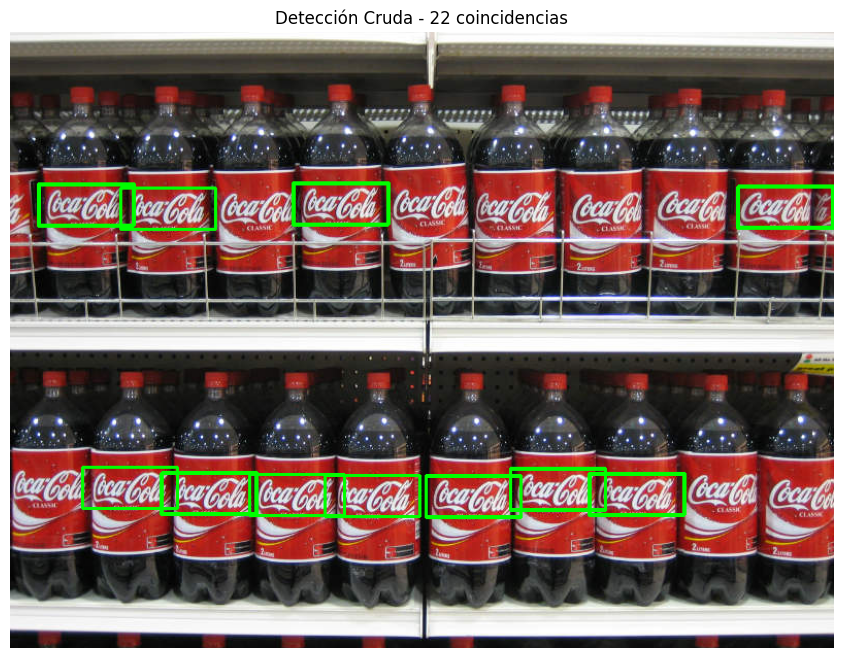

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIGURACIÓN ---
path_img = './images/coca_multi.png'
path_template = './template/pattern.png'

img_rgb = cv2.imread(path_img)
if img_rgb is None: exit()
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2GRAY)

template = cv2.imread(path_template, 0)
# Invertimos para buscar letras blancas
template = cv2.bitwise_not(template)
h_t, w_t = template.shape

img_final = img_rgb.copy()
total_raw_matches = 0

threshold = 0.50

# Escalamos imagenes, ya que el template es muy grande en comparacion con las imagenes a analizar
for escala in np.linspace(0.1, 0.6, 20):
    w_new = int(w_t * escala)
    h_new = int(h_t * escala)
    
    if w_new > img_gray.shape[1] or h_new > img_gray.shape[0]: continue
    
    t_resized = cv2.resize(template, (w_new, h_new))
    
    # Template Matching
    res = cv2.matchTemplate(img_gray, t_resized, cv2.TM_CCOEFF_NORMED)
    
    loc = np.where(res >= threshold)
    
    # Dibujar TODOS los puntos que pasaron el umbral
    puntos = list(zip(*loc[::-1]))
    total_raw_matches += len(puntos)
    
    for pt in puntos:
        cv2.rectangle(img_final, pt, (pt[0] + w_new, pt[1] + h_new), (0, 255, 0), 2)


plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(img_final, cv2.COLOR_BGR2RGB))
plt.title(f"Detección Cruda - {total_raw_matches} coincidencias")
plt.axis('off')
plt.show()

## Punto 3

--- Procesando 7 imágenes ---


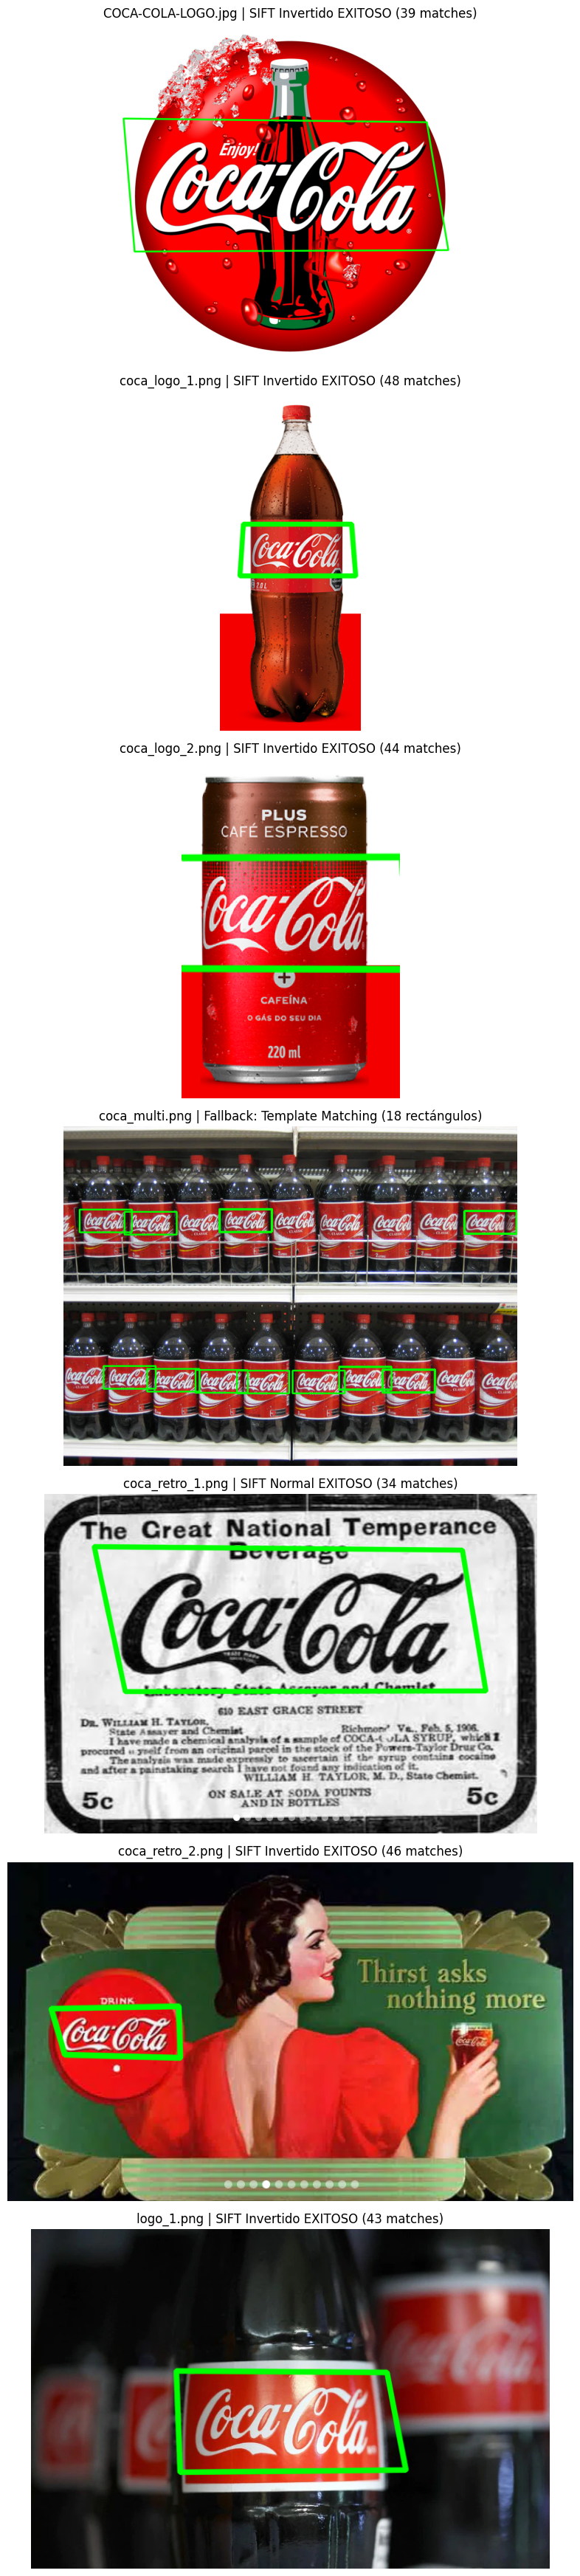

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ==========================================
# 1. FUNCIONES DE CONFIGURACIÓN Y CARGA
# ==========================================

def cargar_y_procesar_template(path_template):
    """Carga el template y genera sus versiones normal e invertida."""
    img = cv2.imread(path_template)
    if img is None:
        raise FileNotFoundError(f"Error: No se encontró el template en {path_template}")
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    inverted = cv2.bitwise_not(gray)
    h, w = gray.shape
    return gray, inverted, h, w

def inicializar_detectores(template_gray, template_inv):
    """Inicializa SIFT y pre-calcula los descriptores del template."""
    sift = cv2.SIFT_create()
    
    # Detectar en ambas versiones del template (competencia de contraste)
    kp_t, des_t = sift.detectAndCompute(template_inv, None)
    kp_g, des_g = sift.detectAndCompute(template_gray, None)
    
    # Configurar Matcher (Norma L2 para SIFT)
    bf = cv2.BFMatcher()
    
    return sift, bf, kp_t, des_t, kp_g, des_g

# ==========================================
# 2. FUNCIONES DE PROCESAMIENTO (CORE)
# ==========================================

def intentar_sift(img_gray, img_draw, sift, bf, datos_template, min_matches=30):
    """
    Intenta detectar el objeto usando SIFT.
    Retorna: (Exito (bool), Imagen con dibujo, Mensaje de estado)
    """
    kp_t, des_t, kp_g, des_g, h_t, w_t = datos_template
    
    # 1. Detectar en la escena
    kp_s, des_s = sift.detectAndCompute(img_gray, None)
    
    if des_s is None or len(kp_s) <= 4:
        return False, img_draw, "SIFT: Insuficientes keypoints"

    # 2. Matching Dual (Normal e Invertido)
    try:
        matches_inv = bf.knnMatch(des_t, des_s, k=2)
        matches_norm = bf.knnMatch(des_g, des_s, k=2)
    except:
        return False, img_draw, "SIFT: Error en matching"

    # 3. Filtrado por Ratio Test
    def filtrar_matches(matches):
        return [m for m, n in matches if m.distance < 0.8 * n.distance]

    good_inv = filtrar_matches(matches_inv)
    good_norm = filtrar_matches(matches_norm)

    # 4. Elegir el mejor conjunto
    if len(good_norm) > len(good_inv):
        good_matches = good_norm
        kp_template = kp_g
        tipo = "Normal"
    else:
        good_matches = good_inv
        kp_template = kp_t
        tipo = "Invertido"

    # 5. Verificación Geométrica (Homografía)
    # Aquí usamos el umbral alto que definiste en tu código (> 30 matches)
    if len(good_matches) > min_matches:
        src_pts = np.float32([kp_template[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
        dst_pts = np.float32([kp_s[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

        M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 10.0)

        if M is not None:
            pts = np.float32([[0, 0], [0, h_t-1], [w_t-1, h_t-1], [w_t-1, 0]]).reshape(-1, 1, 2)
            try:
                dst = cv2.perspectiveTransform(pts, M)
                img_resultado = cv2.polylines(img_draw, [np.int32(dst)], True, (0, 255, 0), 5, cv2.LINE_AA)
                return True, img_resultado, f"SIFT {tipo} EXITOSO ({len(good_matches)} matches)"
            except:
                pass
    
    return False, img_draw, f"SIFT Falló ({len(good_matches)} matches < {min_matches})"

def ejecutar_template_matching(img_gray, img_draw, template_inv, h_t, w_t, threshold=0.5):
    """
    Ejecuta Template Matching Multiescala si SIFT falla.
    Retorna: (Imagen con dibujo, Mensaje de estado)
    """
    total_matches = 0
    img_resultado = img_draw.copy()

    # Barrido de escalas (0.1 a 0.6)
    for escala in np.linspace(0.1, 0.6, 20):
        w_new = int(w_t * escala)
        h_new = int(h_t * escala)
        
        if w_new > img_gray.shape[1] or h_new > img_gray.shape[0]: continue
        
        # Resize del template
        t_resized = cv2.resize(template_inv, (w_new, h_new))
        
        # Matching
        res = cv2.matchTemplate(img_gray, t_resized, cv2.TM_CCOEFF_NORMED)
        
        # Filtrar por umbral
        loc = np.where(res >= threshold)
        puntos = list(zip(*loc[::-1]))
        total_matches += len(puntos)
        
        for pt in puntos:
            cv2.rectangle(img_resultado, pt, (pt[0] + w_new, pt[1] + h_new), (0, 255, 0), 2)

    return img_resultado, f"Fallback: Template Matching ({total_matches} rectángulos)"

# ==========================================
# 3. BLOQUE PRINCIPAL (MAIN)
# ==========================================

# Configuración
carpeta_imagenes = './images/'
path_template = './template/pattern.png'

# 1. Carga inicial
try:
    t_gray, t_inv, h_t, w_t = cargar_y_procesar_template(path_template)
    sift, bf, kp_t, des_t, kp_g, des_g = inicializar_detectores(t_gray, t_inv)
except Exception as e:
    print(e)
    

# Empaquetamos datos del template para pasarlos fácil
datos_template_sift = (kp_t, des_t, kp_g, des_g, h_t, w_t)

# Listar archivos
archivos = [f for f in os.listdir(carpeta_imagenes) if f.lower().endswith(('.jpg', '.png'))]
archivos.sort()

# Configurar visualización
plt.figure(figsize=(15, 5 * len(archivos)))
print(f"--- Procesando {len(archivos)} imágenes ---")

for i, archivo in enumerate(archivos):
    path_full = os.path.join(carpeta_imagenes, archivo)
    img_scene = cv2.imread(path_full)
    if img_scene is None: continue

    img_gray = cv2.cvtColor(img_scene, cv2.COLOR_BGR2GRAY)
    img_final = img_scene.copy()
    estado = ""

    # --- LÓGICA DE DECISIÓN ---
    
    # PASO 1: Intentar SIFT
    exito_sift, img_sift, msg_sift = intentar_sift(img_gray, img_final, sift, bf, datos_template_sift, min_matches=30)
    
    if exito_sift:
        # Si SIFT funcionó, nos quedamos con eso
        img_final = img_sift
        estado = msg_sift
    else:
        # PASO 2: Si SIFT falló, usar Template Matching
        threshold = 0.5
        img_tm, msg_tm = ejecutar_template_matching(img_gray, img_final, t_inv, h_t, w_t, threshold)
        img_final = img_tm
        estado = msg_tm

    # Visualizar
    plt.subplot(len(archivos), 1, i+1)
    plt.imshow(cv2.cvtColor(img_final, cv2.COLOR_BGR2RGB))
    plt.title(f"{archivo} | {estado}")
    plt.axis('off')

plt.tight_layout()
plt.show()

